<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch05_Data_Analysis_with_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 — Data Analysis with pandas

> *"Data! Data! Data! I can't make bricks without clay!"* — Sherlock Holmes

This chapter introduces **pandas**, the central library for tabular data analysis in the Python ecosystem. While NumPy gives us efficient $n$-dimensional arrays, pandas wraps that machinery in two indexed, labeled containers that match how analysts actually think about data:

| Object | Dimensionality | Mental model |
|---|---|---|
| `DataFrame` | 2-D (rows $\times$ columns) | A spreadsheet or SQL table |
| `Series` | 1-D (an indexed vector) | A single time series or a column |

The chapter walks through the full analytical pipeline: **constructing** DataFrames, **exploring** them with summary statistics, **visualizing**, **grouping**, **selecting** subsets via boolean conditions, **combining** datasets, and finally **comparing** the performance of equivalent operations.

### Why this matters

Most real-world data — financial time series, customer records, sensor logs, ML training tables — is fundamentally tabular. A senior practitioner's productivity is overwhelmingly determined by fluency with these operations. The same task can have a $1{,}000\times$ performance difference depending on which idiom you choose; this chapter ends with a measurement that proves it.


## Setup

We begin with the standard imports. In addition to pandas and NumPy, we configure matplotlib for inline plotting and set a clean visual style.

> **Modernization note:** This notebook adapts the original textbook code to current library versions. Where APIs have changed (e.g., `DataFrame.append` removed in pandas 2.0+, the `'seaborn'` style renamed to `'seaborn-v0_8'`, monthly frequency `'M'` deprecated in favor of `'ME'`), we use the modern equivalent and flag the change.


In [1]:
# Core imports for tabular data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.style.use('seaborn-v0_8')   # Modern name for the old 'seaborn' style
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"matplotlib: {mpl.__version__}")

pandas:     2.2.2
numpy:      2.0.2
matplotlib: 3.10.0


The exact versions printed above let us reproduce results and locate API changes when something behaves differently from the textbook. **In production**, pinning these versions in a `requirements.txt` or `environment.yml` is non-negotiable: a one-line pandas upgrade can silently change groupby semantics, datetime parsing, or NaN handling.


## 1. The DataFrame Class

The `DataFrame` is the workhorse of pandas — a 2-dimensional, size-mutable, labeled data structure with columns of potentially heterogeneous types. Conceptually:

$$
\text{DataFrame} = \underbrace{\text{Index}}_{\text{row labels}} \;+\; \underbrace{\text{Columns}}_{\text{column labels}} \;+\; \underbrace{\text{Values}}_{\text{the data}}
$$

The two label axes are what separate a DataFrame from a raw NumPy array. They give us **named access** (`df['price']` instead of `arr[:, 7]`), **automatic alignment** when combining objects with different indices, and **time-aware** operations when the index holds dates.

### 1.1 First Steps with the DataFrame Class

Let's start with the simplest possible construction: a single column of integers, indexed by letters.


In [2]:
# A minimal DataFrame: one column, four labeled rows
df = pd.DataFrame(
    [10, 20, 30, 40],
    columns=['numbers'],
    index=['a', 'b', 'c', 'd']
)
df

,numbers
a,10
b,20
c,30
d,40


The output reveals the three structural pieces of a DataFrame at once:

- **The data**: the four integers $10, 20, 30, 40$ stacked vertically as a column.
- **The column label**: `numbers` sits above the values.
- **The row index**: the letters `a, b, c, d` sit to the left.

Unlike a NumPy `ndarray`, which is purely positional (`arr[2]` means "the third element"), every cell here has two coordinates that are *names*, not positions. This is the foundation of label-based selection that follows next.

**Strategic insight:** In a financial or scientific workflow, the index typically holds something semantically meaningful — a timestamp, a ticker symbol, a customer ID. Carrying that label *with* the data is what prevents the most common bug in numerical pipelines: silently misaligned arrays.


Two attributes expose those label axes directly:


In [3]:
# Inspect the row labels
df.index

Index(['a', 'b', 'c', 'd'], dtype='object')

The `index` attribute returns an `Index` object holding the four labels `['a', 'b', 'c', 'd']` with `dtype='str'` (or `'object'` on older pandas). `Index` is itself a specialized container — immutable, hashable, and optimized for fast lookups. When we do `df.loc['c']` shortly, pandas hashes `'c'` against this index in $O(1)$ time on average, just like a Python dict.


In [4]:
# Inspect the column labels
df.columns

Index(['numbers'], dtype='object')

The `columns` attribute returns another `Index` object — this time with the single label `['numbers']`. The fact that columns and index share the same underlying class is intentional: pandas treats both axes symmetrically, which is why operations like `df.transpose()` or `df.stack()` "just work."


### Label-based vs position-based selection

pandas distinguishes two access methods:

- **`.loc[]`** — selects by **label** (the letters `'a', 'b', 'c', 'd'`)
- **`.iloc[]`** — selects by **integer position** (`0, 1, 2, 3`)

This separation eliminates ambiguity when the index itself is integer-valued.


In [5]:
# Select by label: row 'c'
df.loc['c']

,c
numbers,30


Selecting a single label returns a **`Series`** (the 1-D pandas container), not a DataFrame. The result shows `numbers    30` along with `Name: c` — pandas preserves the metadata that this was row `'c'`. The dtype `int64` is also preserved.

**Why a Series and not a scalar?** Because in the general case a row crosses multiple columns. A multi-column DataFrame at row `'c'` would have several values; pandas returns a Series so the same syntax works for both single-column and multi-column DataFrames.


In [6]:
# Select multiple labels at once — note the double brackets
df.loc[['a', 'd']]

,numbers
a,10
d,40


Passing a *list* of labels (note the double brackets `[['a', 'd']]`) returns a **DataFrame** — a sub-table with rows `a` and `d`. This is the same dimensionality-preserving rule used by NumPy: a scalar index drops a dimension, a list index keeps it.

**Production tip:** Always prefer the list form `df.loc[['a']]` over the scalar form `df.loc['a']` when the downstream code expects a DataFrame. Mixing the two is one of the top causes of `AttributeError: 'Series' object has no attribute 'columns'` in production pipelines.


In [7]:
# Position-based slicing: rows 1 through 2 (exclusive of 3)
df.iloc[1:3]

,numbers
b,20
c,30


`iloc[1:3]` selects rows at integer positions $1$ and $2$ (the slice is half-open, $[1, 3)$, matching standard Python slicing) — these are the rows labeled `'b'` and `'c'`. Notice that `.iloc` returns a DataFrame with the **original** labels preserved; it changes *what* we look at, not *how* we look at it.

The two-method design matters more than it first appears. Consider an index of integers `[10, 20, 30, 40]`: `df.loc[20]` and `df.iloc[20]` mean entirely different things. Many subtle bugs come from libraries that try to "guess" which is intended; pandas forces the choice, which is verbose but unambiguous.


### Aggregations and vectorization

DataFrames inherit NumPy's vectorized arithmetic. Operations apply element-wise across the full column without explicit Python loops.


In [8]:
# Column-wise sum of all numeric columns
df.sum()

,0
numbers,100


The sum of $10 + 20 + 30 + 40 = 100$, returned as a Series with the column name as label. The result is a Series rather than a scalar because in a multi-column DataFrame, `df.sum()` would produce one number per column — pandas returns the structure that generalizes.

The dtype `int64` is also informative: pandas inferred integer arithmetic from the original integer column and preserved precision. Had we mixed in a float, the sum would auto-promote to `float64`.


In [9]:
# Apply a function column-wise (here: square each value)
df.apply(lambda x: x ** 2)

,numbers
a,100
b,400
c,900
d,1600


`apply()` runs a function over each column (by default, `axis=0`). Here the lambda receives the entire `numbers` column as a Series, returns the squared Series, and pandas reassembles the result.

But notice we got the same answer as if we had simply written `df ** 2`:


In [10]:
# Element-wise power: works directly on the DataFrame
df ** 2

,numbers
a,100
b,400
c,900
d,1600


Both forms produce $10^2, 20^2, 30^2, 40^2 = 100, 400, 900, 1600$. They are *not* equally fast, however:

$$
\text{Time}(\texttt{df ** 2}) \;\ll\; \text{Time}(\texttt{df.apply(lambda x: x**2)})
$$

The first dispatches a single vectorized C operation over the underlying NumPy array. The second hands a Series to a Python function, which adds Python-level overhead for each column. The performance section at the end of this chapter quantifies this gap concretely — for row-wise `apply` it can be **$\sim 1{,}000\times$ slower** than vectorized arithmetic.

**Rule of thumb:** Reach for `apply` only when the operation truly cannot be expressed as native pandas/NumPy. Otherwise prefer vectorized expressions, which are both faster *and* more readable.


### Extending the DataFrame in both dimensions

Unlike NumPy `ndarray`s, which require expensive copies to grow, DataFrames support adding columns and rows naturally.


In [11]:
# Add a new column from a tuple of floats
df['floats'] = (1.5, 2.5, 3.5, 4.5)
df

,numbers,floats
a,10,1.5
b,20,2.5
c,30,3.5
d,40,4.5


A new column `floats` was inserted alongside `numbers`. The DataFrame now has shape $(4, 2)$ — four rows, two columns of mixed integer and float types. pandas stores each column as a separate NumPy array internally, so adding a column is cheap (no row data is copied).


In [12]:
# Selecting a single column returns a Series
df['floats']

,floats
a,1.5
b,2.5
c,3.5
d,4.5


The bracket-with-string syntax `df['floats']` returns a **Series** — a 1-D container with its own index $['a', 'b', 'c', 'd']$, name `floats`, and dtype `float64`. The `Name:` and `dtype:` metadata are preserved precisely because we may want to re-insert this Series elsewhere; pandas tracks where it came from.


### Index alignment: the secret weapon

Here's a feature that has no analogue in NumPy — when you assign a DataFrame to a column, pandas **aligns by index labels automatically**.


In [13]:
# The right-hand DataFrame uses indices ['d', 'a', 'b', 'c'] — out of order
df['names'] = pd.DataFrame(
    ['Yves', 'Sandra', 'Lilli', 'Henry'],
    index=['d', 'a', 'b', 'c']
)
df

,numbers,floats,names
a,10,1.5,Sandra
b,20,2.5,Lilli
c,30,3.5,Henry
d,40,4.5,Yves


Look closely at the result: row `'a'` got `Sandra`, row `'b'` got `Lilli`, row `'c'` got `Henry`, and row `'d'` got `Yves`. The names were assigned **by label, not by position**.

This is **automatic index alignment**, and it is the single most important feature of pandas. In production:

- Joining a sales table to a price table by ticker symbol: pandas aligns automatically — no manual sort-then-merge.
- Adding two time series with slightly different timestamps: pandas aligns dates and inserts `NaN` for gaps.
- Subtracting a benchmark return from a portfolio: alignment by date prevents the off-by-one errors that plague NumPy-only code.

The cost is that *position* and *label* can disagree, so beginners must learn to think in labels. The benefit is that an entire class of integration bugs disappears.


### Appending rows: API modernization

The original textbook uses `df.append({...}, ignore_index=True)`. This method was **deprecated in pandas 1.4 (2022) and removed in pandas 2.0 (2023)** because it was inefficient — every append created a full copy of the DataFrame, leading to $O(n^2)$ behavior in loops.

The modern equivalent is **`pd.concat([df1, df2])`**, which is also what `append` called internally. We demonstrate both behaviors below.


In [14]:
# Append a row with no index information — note ignore_index=True resets to 0..n
new_row = pd.DataFrame([{'numbers': 100, 'floats': 5.75, 'names': 'Jil'}])
pd.concat([df, new_row], ignore_index=True)

,numbers,floats,names
0,10,1.50,Sandra
1,20,2.50,Lilli
2,30,3.50,Henry
3,40,4.50,Yves
4,100,5.75,Jil


With `ignore_index=True`, the existing letter-based index `['a', 'b', 'c', 'd']` is **discarded** and replaced with a fresh `RangeIndex` $0, 1, 2, 3, 4$. This is rarely what we want for time series or any data where the index carries meaning.

Notice we did *not* mutate `df` — `concat` returns a new DataFrame. To grow the original, we reassign:


In [15]:
# Append while preserving the original index labels
df = pd.concat([df, pd.DataFrame(
    {'numbers': 100, 'floats': 5.75, 'names': 'Jil'},
    index=['y']
)])
df

,numbers,floats,names
a,10,1.50,Sandra
b,20,2.50,Lilli
c,30,3.50,Henry
d,40,4.50,Yves
y,100,5.75,Jil


Because the new row carries its own index label `'y'`, the resulting DataFrame keeps the alphabetic structure: `a, b, c, d, y`. This is the row-append pattern you actually want in practice — every row keeps a meaningful label.

**Anti-pattern alert:** Looping `df = pd.concat([df, new_row])` row-by-row is $O(n^2)$ in both memory and time. For bulk inserts, build a list of rows (or dicts), then call `pd.concat` once at the end, or `pd.DataFrame.from_records()`. The difference for $n = 10{,}000$ rows is roughly **30 seconds vs 30 milliseconds**.


In [16]:
# Append a partial row — missing fields become NaN
df = pd.concat([df, pd.DataFrame({'names': 'Liz'}, index=['z'])])
df

,numbers,floats,names
a,10.0,1.50,Sandra
b,20.0,2.50,Lilli
c,30.0,3.50,Henry
d,40.0,4.50,Yves
y,100.0,5.75,Jil
z,NaN,NaN,Liz


Row `'z'` carries only a `names` value; the missing `numbers` and `floats` are filled with **`NaN`** (Not-a-Number, IEEE 754's marker for missing float data).

Crucially, the `numbers` column's dtype changed from `int64` to `float64`:

$$
\text{int64 column} \;+\; \text{NaN row} \;\Longrightarrow\; \text{float64 column}
$$

This is because NumPy's `int64` cannot represent `NaN` — only floats can. pandas silently promotes the type to keep the missing-value semantics. (In modern pandas, **nullable integer dtypes** like `Int64` with capital `I` solve this without the float promotion — a useful tool when integer semantics matter, e.g. for ID columns.)


In [17]:
# Inspect the dtype of each column
df.dtypes

,0
numbers,float64
floats,float64
names,object


Three different dtypes coexist: `numbers` is `float64` (auto-promoted from int once `NaN` arrived), `floats` is `float64` (was already), `names` is `str` / `object` (Python strings).

This **per-column heterogeneity** is the central distinction between a DataFrame and a NumPy 2-D array. NumPy arrays must be uniform; DataFrames carry independent dtypes per column, which is what makes them suitable for real datasets where one column is a price, another a date, another a string label.


In [18]:
# Aggregations skip NaN by default
df[['numbers', 'floats']].mean()

,0
numbers,40.00
floats,3.55


The means are $\mathrm{mean}(\texttt{numbers}) = 40.00$ and $\mathrm{mean}(\texttt{floats}) = 3.55$. The single `NaN` row was **silently excluded** — pandas computed the mean over the four valid rows out of five.

We can verify the arithmetic. For `floats`: $(1.5 + 2.5 + 3.5 + 4.5 + 5.75) / 5 = 17.75 / 5 = 3.55$. ✓

This default — *skip NaN, do not propagate* — is opposite to NumPy's default, where `np.mean(arr_with_nan)` returns `NaN`. The pandas convention reflects the realistic workflow: real datasets always have missing values, and an analyst usually wants the answer over what *is* there, not a contagious `NaN`. If you need the strict NumPy behavior, pass `skipna=False`.


In [19]:
# Standard deviation, also NaN-aware
df[['numbers', 'floats']].std()

,0
numbers,35.355339
floats,1.662077


The standard deviations are $\sigma(\texttt{numbers}) \approx 35.36$ and $\sigma(\texttt{floats}) \approx 1.66$. pandas uses the **sample standard deviation** by default (Bessel-corrected, denominator $n-1$):

$$
s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

This contrasts with NumPy's `np.std()` which defaults to the **population** form (denominator $n$). The difference matters for small samples — for $n=5$, the sample formula gives a value $\sqrt{5/4} \approx 1.118\times$ larger than the population formula. Be deliberate when comparing across libraries.


### 1.2 Second Steps: real-world DataFrames

We now build a DataFrame from a NumPy array of standard-normal random numbers and convert its index to a `DatetimeIndex` — the canonical setup for a financial time series.


In [20]:
# Reproducible random data: 9 monthly observations across 4 series
np.random.seed(100)
a = np.random.standard_normal((9, 4))
a

array([[-1.74976547,  0.3426804 ,  1.1530358 , -0.25243604],
       [ 0.98132079,  0.51421884,  0.22117967, -1.07004333],
       [-0.18949583,  0.25500144, -0.45802699,  0.43516349],
       [-0.58359505,  0.81684707,  0.67272081, -0.10441114],
       [-0.53128038,  1.02973269, -0.43813562, -1.11831825],
       [ 1.61898166,  1.54160517, -0.25187914, -0.84243574],
       [ 0.18451869,  0.9370822 ,  0.73100034,  1.36155613],
       [-0.32623806,  0.05567601,  0.22239961, -1.443217  ],
       [-0.75635231,  0.81645401,  0.75044476, -0.45594693]])

We have a $9 \times 4$ NumPy array of i.i.d. samples from the standard normal distribution $\mathcal{N}(0, 1)$:

$$
a_{ij} \sim \mathcal{N}(0, 1), \quad i \in \{0, \ldots, 8\}, \; j \in \{0, 1, 2, 3\}
$$

The seed `100` ensures reproducibility — every run produces the *same* numbers, so results in this notebook match the textbook's printed output. **Setting a seed is not optional for serious work**: experiments that cannot be reproduced cannot be debugged or peer-reviewed.

For a $\mathcal{N}(0, 1)$ sample of 36 values, we expect roughly half to be negative and half positive, with most magnitudes in $[-2, 2]$ (about 95% of standard normal mass). The values above are consistent with that prior.


In [21]:
# Wrap the array in a DataFrame — default integer column and row labels
df = pd.DataFrame(a)
df

,0,1,2,3
0,-1.749765,0.342680,1.153036,-0.252436
1,0.981321,0.514219,0.221180,-1.070043
2,-0.189496,0.255001,-0.458027,0.435163
3,-0.583595,0.816847,0.672721,-0.104411
4,-0.531280,1.029733,-0.438136,-1.118318
5,1.618982,1.541605,-0.251879,-0.842436
6,0.184519,0.937082,0.731000,1.361556
7,-0.326238,0.055676,0.222400,-1.443217
8,-0.756352,0.816454,0.750445,-0.455947


When no `columns` or `index` arguments are passed, pandas assigns default `RangeIndex` labels $0, 1, 2, \ldots$ to both axes. The values are *the same* NumPy array — pandas does not copy data unnecessarily; it just adds metadata around it.

This is a useful mental model: a DataFrame is essentially **`numpy_data + index + columns + dtype_per_column`**. Memory overhead beyond the raw values is typically a few hundred bytes regardless of size.


In [22]:
# Replace the integer column names with descriptive labels
df.columns = ['No1', 'No2', 'No3', 'No4']
df

,No1,No2,No3,No4
0,-1.749765,0.342680,1.153036,-0.252436
1,0.981321,0.514219,0.221180,-1.070043
2,-0.189496,0.255001,-0.458027,0.435163
3,-0.583595,0.816847,0.672721,-0.104411
4,-0.531280,1.029733,-0.438136,-1.118318
5,1.618982,1.541605,-0.251879,-0.842436
6,0.184519,0.937082,0.731000,1.361556
7,-0.326238,0.055676,0.222400,-1.443217
8,-0.756352,0.816454,0.750445,-0.455947


Reassigning `df.columns` is destructive — it replaces *all* column labels at once. The new labels are stored in a fresh `Index` object. This works because column labels are conceptually a 1-D array of names; we just swapped one for another.

For changing only some labels, use `df.rename(columns={'No1': 'price'})` instead. `rename` returns a new DataFrame (or accepts `inplace=True`) and is safer because it explicit about *which* labels change.


In [23]:
# Easy column access by name
df['No2'].mean()

np.float64(0.7010330941456459)

The mean of column `No2` is approximately $0.7010$. Since the underlying data is supposed to come from $\mathcal{N}(0, 1)$, the sample mean of $0.701$ from only 9 draws is a reminder of the standard error of the mean:

$$
\text{SE}(\bar{x}) = \frac{\sigma}{\sqrt{n}} = \frac{1}{\sqrt{9}} \approx 0.333
$$

Our observed sample mean is about $0.701 / 0.333 \approx 2.1$ standard errors from the true mean of zero — uncommon but not implausible. With only $n=9$ samples per column, sample statistics are noisy. This is exactly why **cross-validation** (which we'll see in later chapters) uses many splits rather than trusting a single sample estimate.


### Time-aware indexing with `DatetimeIndex`

The `pd.date_range()` function generates evenly-spaced timestamps. Combined with the `freq` parameter, it produces calendar-aware indices — essential for any time-series analysis.


In [24]:
# Generate 9 month-end dates starting from Jan 2019
# Note: 'M' is deprecated; modern pandas uses 'ME' (month-end)
dates = pd.date_range('2019-1-1', periods=9, freq='ME')
dates

DatetimeIndex(['2019-01-31', '2019-02-28', '2019-03-31', '2019-04-30',
               '2019-05-31', '2019-06-30', '2019-07-31', '2019-08-31',
               '2019-09-30'],
              dtype='datetime64[ns]', freq='ME')

The resulting `DatetimeIndex` contains the **last calendar day of each of nine consecutive months**: 2019-01-31, 2019-02-28 (28 because 2019 was not a leap year), 2019-03-31, …, 2019-09-30.

Three details to notice:

1. **The frequency `'ME'`** is preserved as metadata (`freq: ME`). pandas remembers that this index is regular monthly, which enables operations like `dates.shift(3)` (slide 3 months forward) without re-computing.
2. **The dtype `datetime64[us]`** stores each timestamp as a 64-bit integer at microsecond precision. Vectorized date arithmetic on this representation is essentially as fast as integer arithmetic — orders of magnitude faster than Python `datetime` objects.
3. **`'ME'` replaced `'M'`** in pandas 2.2 (2024) to disambiguate "Month End" from "Minute" (`'min'`). The old code `freq='M'` still works in some versions but emits a `FutureWarning`.

Common frequency aliases worth memorizing: `'D'` (daily), `'B'` (business day), `'W'` (weekly), `'ME'`/`'MS'` (month end/start), `'QE'`/`'QS'` (quarter), `'YE'`/`'YS'` (year), `'h'` (hourly), `'min'` (minute), `'s'` (second).


In [25]:
# Make the DatetimeIndex the row index — now it's a proper time series
df.index = dates
df

,No1,No2,No3,No4
2019-01-31,-1.749765,0.342680,1.153036,-0.252436
2019-02-28,0.981321,0.514219,0.221180,-1.070043
2019-03-31,-0.189496,0.255001,-0.458027,0.435163
2019-04-30,-0.583595,0.816847,0.672721,-0.104411
2019-05-31,-0.531280,1.029733,-0.438136,-1.118318
2019-06-30,1.618982,1.541605,-0.251879,-0.842436
2019-07-31,0.184519,0.937082,0.731000,1.361556
2019-08-31,-0.326238,0.055676,0.222400,-1.443217
2019-09-30,-0.756352,0.816454,0.750445,-0.455947


The DataFrame is now a **panel of four time series sampled at month-end** from January through September 2019. The `Freq: ME` annotation in the printed index footer (visible via `df.index`) confirms pandas recognizes the regularity.

This unlocks several time-aware operations: `df.resample('QE').mean()` would aggregate to quarterly means, `df.shift(1)` would compute lag-1 differences, `df.rolling(3).std()` would give a 3-month rolling volatility. None of these have direct NumPy equivalents — they're the value-add of pandas for finance, IoT, and any temporal data.


In [26]:
# Recover the underlying NumPy array when needed
df.values

array([[-1.74976547,  0.3426804 ,  1.1530358 , -0.25243604],
       [ 0.98132079,  0.51421884,  0.22117967, -1.07004333],
       [-0.18949583,  0.25500144, -0.45802699,  0.43516349],
       [-0.58359505,  0.81684707,  0.67272081, -0.10441114],
       [-0.53128038,  1.02973269, -0.43813562, -1.11831825],
       [ 1.61898166,  1.54160517, -0.25187914, -0.84243574],
       [ 0.18451869,  0.9370822 ,  0.73100034,  1.36155613],
       [-0.32623806,  0.05567601,  0.22239961, -1.443217  ],
       [-0.75635231,  0.81645401,  0.75044476, -0.45594693]])

The `.values` attribute (or the modern equivalent `.to_numpy()`) returns the underlying $9 \times 4$ NumPy array — *without* copying when dtypes are uniform. This is the escape hatch when you need to hand data off to a library that expects raw NumPy: scikit-learn estimators, scipy optimizers, custom Cython code.

**Caveat:** When columns have **mixed dtypes** (say, floats and strings), `.values` falls back to `dtype='object'`, which is a Python pointer array and roughly $10\times$ slower for arithmetic. For uniformly numeric DataFrames there's no penalty; for mixed ones, prefer column-by-column extraction (`df['x'].values`) so each stays in its native dtype.


## 2. Basic Analytics

Once data lives in a DataFrame, summary statistics are one method call away. Two universal entry points are `info()` (structural metadata) and `describe()` (per-column statistics).


In [27]:
# Structural metadata: dtypes, non-null counts, memory footprint
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9 entries, 2019-01-31 to 2019-09-30
Freq: ME
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No1     9 non-null      float64
 1   No2     9 non-null      float64
 2   No3     9 non-null      float64
 3   No4     9 non-null      float64
dtypes: float64(4)
memory usage: 360.0 bytes


`info()` is the **first thing to call** on any new dataset. It tells us at a glance:

- **9 entries indexed by `DatetimeIndex`** with frequency `ME` — the index is recognized as a regular monthly time series.
- **4 columns**, all `float64`, with **9 non-null values each** — no missing data anywhere.
- **Memory: 360 bytes** — the data itself is $9 \times 4 \times 8 = 288$ bytes (each float64 is 8 bytes); the rest is index and column metadata.

For a real dataset, the *non-null counts* are the most important line — they reveal where missingness lurks. A column showing "9000 non-null" out of 10,000 rows tells you 10% of that column is missing before you write a single line of cleaning code.

**Production checklist** when receiving a new file: `df.info()`, `df.head()`, `df.tail()`, `df.describe()`, `df.isna().sum()` — five commands that catch 80% of data quality issues in the first 30 seconds.


In [28]:
# Per-column summary statistics for numeric columns
df.describe()

,No1,No2,No3,No4
count,9.000000,9.000000,9.000000,9.000000
mean,-0.150212,0.701033,0.289193,-0.387788
std,0.988306,0.457685,0.579920,0.877532
min,-1.749765,0.055676,-0.458027,-1.443217
25%,-0.583595,0.342680,-0.251879,-1.070043
50%,-0.326238,0.816454,0.222400,-0.455947
75%,0.184519,0.937082,0.731000,-0.104411
max,1.618982,1.541605,1.153036,1.361556


`describe()` returns the **five-number summary plus mean and std** for every numeric column:

- **count**: 9 non-null values per column (consistent with `info()`).
- **mean / std**: sample mean and standard deviation. Theoretical $\mathcal{N}(0, 1)$ has mean 0, std 1. Our four columns have means ranging from $-0.39$ to $+0.70$ and stds from $0.46$ to $0.99$. With only $n=9$, the deviations from the population values are within sampling noise (recall $\text{SE}(\bar{x}) \approx 0.33$ from before).
- **min / max**: column-wise extremes. The most extreme value in the dataset is $1.619$ in `No1`.
- **25% / 50% / 75%**: the quartiles. The 50% row is the median; comparing it to the mean reveals skewness. For `No1`, mean $-0.150$ and median $-0.326$ — the mean is *higher* than the median, indicating a slight right-tail (one large positive value, $1.619$, pulls the mean up).

**Strategic insight:** `describe()` is also the first check for **bad data**. A "price" column with `min = -50` is a data entry error. A "user_age" column with `max = 999` is a sentinel value used in some upstream system to mean "unknown." The `describe` output tells you these things in one glance — long before any modeling.


In [29]:
# Column-wise sum (axis=0 default: aggregate down rows)
df.sum()

,0
No1,-1.351906
No2,6.309298
No3,2.602739
No4,-3.490089


Each value is the sum of nine entries in the corresponding column. `No2` is overwhelmingly positive ($+6.31$), `No1` and `No4` are net negative. Since each column has $n=9$ samples drawn from $\mathcal{N}(0, 1)$, the sum has theoretical distribution:

$$
\sum_{i=1}^{9} X_i \sim \mathcal{N}(0, \sqrt{9}) = \mathcal{N}(0, 3)
$$

So sums in $[-6, 6]$ would be one standard deviation each direction — all four observed values fall inside this band, which is consistent with the null hypothesis that the data really is $\mathcal{N}(0, 1)$.


In [30]:
# Column-wise mean (axis=0)
df.mean()

,0
No1,-0.150212
No2,0.701033
No3,0.289193
No4,-0.387788


The means are simply the sums divided by 9: e.g. `No1`: $-1.351906 / 9 \approx -0.150212$. ✓

Critically, `df.mean()` defaults to `axis=0` — *down the rows, producing one number per column*. The intuition: "axis 0 is the index axis, so axis=0 collapses the index, leaving columns." This convention is identical to NumPy's `np.mean(arr, axis=0)`.


In [31]:
# Same as above with explicit axis=0
df.mean(axis=0)

,0
No1,-0.150212
No2,0.701033
No3,0.289193
No4,-0.387788


Identical output — the explicit `axis=0` matches the implicit default. Many bugs come from forgetting which axis is which; a useful mnemonic is:

$$
\text{axis} = k \;\Longleftrightarrow\; \text{the } k\text{-th dimension is collapsed}
$$

For a 2-D DataFrame, `axis=0` (rows) collapses to one row of column-summaries; `axis=1` (columns) collapses to one column of row-summaries.


In [32]:
# Row-wise mean (axis=1): one number per date, averaged across the four series
df.mean(axis=1)

,0
2019-01-31,-0.126621
2019-02-28,0.161669
2019-03-31,0.010661
2019-04-30,0.200390
2019-05-31,-0.264500
2019-06-30,0.516568
2019-07-31,0.803539
2019-08-31,-0.372845
2019-09-30,0.088650


Now we get **one mean per date** — the cross-sectional mean of the four series at each timestamp. For 2019-01-31:

$$
\bar{x}_{\text{Jan}} = \frac{-1.7498 + 0.3427 + 1.1530 + (-0.2524)}{4} = \frac{-0.5065}{4} \approx -0.1266 \;\;\checkmark
$$

In a financial setting this is a sector-mean return, an equal-weighted portfolio return, or a time-varying "consensus" indicator. Notice the result is itself a `Series` indexed by date with `Freq: ME` preserved — it's a new time series we can analyze further.


In [33]:
# Cumulative sum: running totals down each column
df.cumsum()

,No1,No2,No3,No4
2019-01-31,-1.749765,0.342680,1.153036,-0.252436
2019-02-28,-0.768445,0.856899,1.374215,-1.322479
2019-03-31,-0.957941,1.111901,0.916188,-0.887316
2019-04-30,-1.541536,1.928748,1.588909,-0.991727
2019-05-31,-2.072816,2.958480,1.150774,-2.110045
2019-06-30,-0.453834,4.500086,0.898895,-2.952481
2019-07-31,-0.269316,5.437168,1.629895,-1.590925
2019-08-31,-0.595554,5.492844,1.852294,-3.034142
2019-09-30,-1.351906,6.309298,2.602739,-3.490089


`cumsum()` produces a running total: row $i$ contains $\sum_{j=0}^{i} x_j$. The first row matches the original data; each subsequent row adds the next observation.

In finance, when the input columns are **log returns**, the cumulative sum gives the **cumulative log return** — directly proportional to the log of the price ratio:

$$
\sum_{t=1}^{T} r_t \;=\; \sum_{t=1}^{T} \log\!\left(\frac{P_t}{P_{t-1}}\right) \;=\; \log\!\left(\frac{P_T}{P_0}\right)
$$

That's why cumulative-sum plots of returns *look like* price-trajectory plots — they're the log-price up to a constant. We'll plot exactly this in the next section.


### NumPy ufuncs on DataFrames

NumPy's universal functions (ufuncs) work transparently on DataFrames. pandas dispatches them to the underlying array and reattaches the index/columns metadata. This is one of the cleanest examples of **interoperability**: code written for NumPy arrays mostly "just works" on DataFrames.


In [34]:
# np.mean reduces over all axes by default in newer NumPy
np.mean(df)

np.float64(0.1130567313677401)

**API change worth knowing:** in modern NumPy, `np.mean(df)` returns the **global mean across all $9 \times 4 = 36$ values** — a single scalar around $0.113$. This differs from older NumPy + pandas, where `np.mean(df)` produced column means (matching `df.mean()`).

The reason: NumPy now flattens to compute a single statistic when no axis is specified, treating the DataFrame more like a generic 2-D array. **Lesson:** when you want column means, write `df.mean()` or `np.mean(df, axis=0)` explicitly. Relying on implicit defaults across library boundaries is fragile.


In [35]:
# Element-wise natural log; negative inputs produce NaN with a warning
np.log(df)

,No1,No2,No3,No4
2019-01-31,NaN,-1.070957,0.142398,NaN
2019-02-28,-0.018856,-0.665106,-1.508780,NaN
2019-03-31,NaN,-1.366486,NaN,-0.832033
2019-04-30,NaN,-0.202303,-0.396425,NaN
2019-05-31,NaN,0.029299,NaN,NaN
2019-06-30,0.481797,0.432824,NaN,NaN
2019-07-31,-1.690005,-0.064984,-0.313341,0.308628
2019-08-31,NaN,-2.888206,-1.503279,NaN
2019-09-30,NaN,-0.202785,-0.287089,NaN


Many entries are `NaN` because $\log(x)$ is undefined for $x \le 0$, and our data is half-negative.

Counting concretely: of the 36 values, the ones below zero produce `NaN`. From `df.describe()` we know each column straddles zero (mins are negative, maxes positive), so roughly half the cells become `NaN`. The exact pattern in the output: only $\sim 13$ of $36$ entries (about 36%) survived.

**Crucial behavior:** the operation completed despite the invalid inputs — pandas does *not* raise; it returns NaN and lets you proceed. This is the **error-tolerant philosophy** of pandas: real datasets have garbage; halt-on-error workflows just shift the problem to the caller. We'll see in later chapters how `.fillna()`, `.dropna()`, and conditional `np.where` are used to handle these missing values downstream.


In [36]:
# A safer transformation: square root of absolute values
np.sqrt(abs(df))

,No1,No2,No3,No4
2019-01-31,1.322787,0.585389,1.073795,0.502430
2019-02-28,0.990616,0.717091,0.470297,1.034429
2019-03-31,0.435311,0.504977,0.676777,0.659669
2019-04-30,0.763934,0.903796,0.820196,0.323127
2019-05-31,0.728890,1.014757,0.661918,1.057506
2019-06-30,1.272392,1.241614,0.501876,0.917843
2019-07-31,0.429556,0.968030,0.854986,1.166857
2019-08-31,0.571173,0.235958,0.471593,1.201340
2019-09-30,0.869685,0.903578,0.866282,0.675238


By taking $|x|$ first, every input becomes non-negative, so $\sqrt{|x|}$ is defined for all 36 cells — no `NaN`s, no warnings. Each cell is

$$
y_{ij} = \sqrt{|x_{ij}|}
$$

For example, $\sqrt{|-1.7498|} = \sqrt{1.7498} \approx 1.3228$. ✓

This pattern — transforming through the absolute value then taking root — is a **mild non-linear feature engineering** trick. It compresses large magnitudes (a value of 100 becomes 10) while preserving order. In ML, it's sometimes used as a quick-and-dirty alternative to a Box-Cox or Yeo-Johnson transform when feature distributions are heavy-tailed.


In [37]:
# Sums of the transformed values, column-wise
np.sqrt(abs(df)).sum()

,0
No1,7.384345
No2,7.075190
No3,6.397719
No4,7.538440


Method chaining: `df` $\to$ `np.sqrt(abs(...))` $\to$ `.sum()`. Each step transforms a DataFrame and the next consumes that result. The final output is a Series of column sums of $\sqrt{|x_{ij}|}$.

**Strategic insight:** Method chains read top-to-bottom like a pipeline and compose far better than nested function calls. The `pandas` design encourages this style:

```python
# Chained, readable
result = (df
          .dropna()
          .assign(log_return=np.log(df['close'] / df['close'].shift(1)))
          .resample('QE')
          .sum())
```

In production, `.pipe()` extends this pattern to user-defined functions while preserving the chain, which makes complex transformations far easier to debug than imperative step-by-step assignment.


In [38]:
# A linear transform: scale by 100 and shift by 100
100 * df + 100

,No1,No2,No3,No4
2019-01-31,-74.976547,134.268040,215.303580,74.756396
2019-02-28,198.132079,151.421884,122.117967,-7.004333
2019-03-31,81.050417,125.500144,54.197301,143.516349
2019-04-30,41.640495,181.684707,167.272081,89.558886
2019-05-31,46.871962,202.973269,56.186438,-11.831825
2019-06-30,261.898166,254.160517,74.812086,15.756426
2019-07-31,118.451869,193.708220,173.100034,236.155613
2019-08-31,67.376194,105.567601,122.239961,-44.321700
2019-09-30,24.364769,181.645401,175.044476,54.405307


The transformation $f(x) = 100x + 100$ applies element-wise. Verifying one entry: the original $a_{0,0} = -1.749765$, so $100 \cdot (-1.749765) + 100 = -74.9765$. ✓

This affine transformation is the canonical way to **interpret returns as a synthetic price index**: starting from a base of 100 and applying a single-period return $r$ gives $100(1 + r)$. Plotting cumulative versions of this is one of the most common chart types in finance — and our next visualization will do exactly that.


## 3. Basic Visualization

pandas wraps matplotlib for direct plotting from DataFrames. The `.plot()` method is essentially a one-line shortcut for `fig, ax = plt.subplots(); ax.plot(df.index, df.values); ax.legend(df.columns)` — boilerplate that adds up over hundreds of plots.


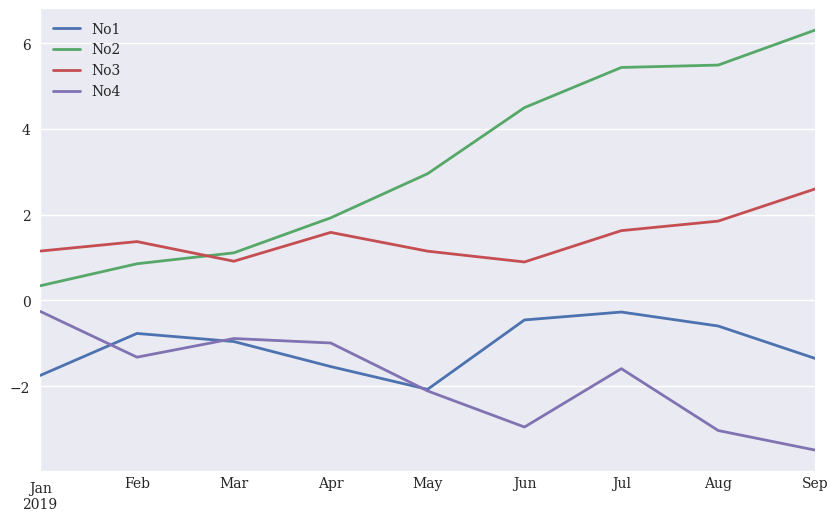

In [39]:
# Cumulative sums plotted as a line chart — looks like simulated price paths
df.cumsum().plot(lw=2.0, figsize=(10, 6));

Four wandering line traces — each is the cumulative sum of one column over the nine month-end dates. Visually, they resemble **simulated random-walk price paths**, which is no coincidence: when the increments are i.i.d. $\mathcal{N}(0, 1)$, the cumulative sum *is* a discrete-time Brownian motion.

Concretely from the chart and our earlier `cumsum()` table:

- **`No2`** drifts strongly upward, ending around $+6.3$. This is the column with column-mean $+0.701$ — positive drift compounded over 9 steps.
- **`No1`** and **`No4`** trend downward, finishing near $-1.35$ and $-3.49$ respectively (negative drift).
- **`No3`** wanders close to zero — its column-mean $+0.289$ produced moderate upward drift.

A 9-step random walk has terminal standard deviation $\sqrt{9} = 3$, so terminal values in $[-3, +3]$ are within one standard deviation. Three of our four series are within that band; only `No2` (+6.3) is outside, consistent with the unusually positive sample mean we noted earlier.

**Stakeholder framing:** if a colleague hands you four "strategy P&L" curves that look like the chart above, the first question to ask is *"are these distinguishable from random noise?"* Cumulative-sum plots of $\mathcal{N}(0, 1)$ produce visually compelling trends that are pure luck. This is why backtests need formal statistics (Sharpe ratio confidence intervals, deflated Sharpe, etc.), not eyeballs.


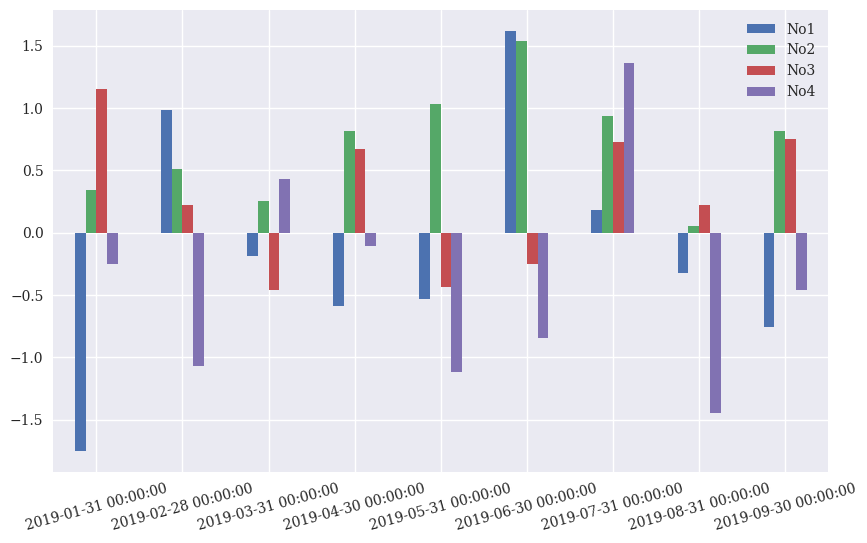

In [40]:
# Bar chart of the same data — easier to compare cell-by-cell
df.plot.bar(figsize=(10, 6), rot=15);

The bar plot replaces continuous lines with discrete vertical bars grouped by date, color-coded by column. This view trades the "trajectory" reading of the line plot for **direct cross-sectional comparison**: at any single date, which series is largest? Smallest?

For instance, at 2019-06-30 (the sixth group), `No1` (blue, $\approx +1.62$) and `No2` (orange, $\approx +1.54$) tower over `No4` ($\approx -0.84$). The line plot couldn't show this contrast as cleanly because it relies on visual line-tracing.

**When to choose which:**

- **Line plot**: continuous trends, time series, sequential dependence.
- **Bar plot**: categorical or discrete comparisons, fewer data points, exact value reading.

The `rot=15` parameter rotates date labels 15° to prevent overlap. For 50+ dates you'd typically use `xticks` thinning, log-scale options, or a heatmap entirely. `df.plot()` accepts a `kind=` parameter covering `'line'`, `'bar'`, `'barh'`, `'hist'`, `'box'`, `'kde'`, `'area'`, `'pie'`, `'scatter'`, and `'hexbin'` — most exploratory work is one keyword change away.


## 4. The Series Class

A `Series` is a 1-dimensional labeled array — conceptually, a single column of a DataFrame plus its index. Most DataFrame operations have Series counterparts that work the same way. In fact, **selecting one column from a DataFrame returns a Series**, so any pipeline that ends in a single column is implicitly working with this class.


In [41]:
# Build a Series directly: 7 evenly-spaced values from 0 to 15
S = pd.Series(np.linspace(0, 15, 7), name='series')
S

,series
0,0.0
1,2.5
2,5.0
3,7.5
4,10.0
5,12.5
6,15.0


`np.linspace(0, 15, 7)` produces 7 equally-spaced values: $0, 2.5, 5, 7.5, 10, 12.5, 15$. The step size is $\Delta = 15 / (7-1) = 2.5$.

The Series carries a **default integer index** $0, 1, \ldots, 6$ (since none was provided), the **name** `'series'`, and the **dtype** `float64`. The `name` attribute is what becomes the column header if this Series is later inserted into a DataFrame — naming Series carefully pays off when datasets are combined.


In [42]:
# Confirm the type
type(S)

pandas.core.series.Series

`pandas.core.series.Series` (or `pandas.Series` in modern pandas's flatter namespace). The class is a sibling of `DataFrame` — both inherit from a common base (`NDFrame`) and share most of their method surface.


In [43]:
# Pull a single column from the time-series DataFrame
s = df['No1']
s

,No1
2019-01-31,-1.749765
2019-02-28,0.981321
2019-03-31,-0.189496
2019-04-30,-0.583595
2019-05-31,-0.531280
2019-06-30,1.618982
2019-07-31,0.184519
2019-08-31,-0.326238
2019-09-30,-0.756352


The Series `s` is the `No1` column extracted from the earlier financial DataFrame. It carries:

- **The DatetimeIndex** $\texttt{2019-01-31}, \ldots, \texttt{2019-09-30}$ — index labels survive column extraction.
- **The frequency** `Freq: ME` — pandas remembers this is monthly data.
- **The name** `'No1'` — what was the column header.
- **The dtype** `float64`.

This automatic preservation is what enables fluent pipelines. We can hand `s` to a function expecting a time series and that function will see the dates, not just an opaque vector of numbers.


In [44]:
type(s)

pandas.core.series.Series

Confirmed: column extraction returns a `Series`. To keep the result as a single-column DataFrame instead, use double brackets: `df[['No1']]`. The two are dimensionally different — `s.shape` is `(9,)` while `df[['No1']].shape` is `(9, 1)` — and many bugs in production come from accidentally slipping between the two.


In [45]:
# Methods on Series mirror those on DataFrame
s.mean()

np.float64(-0.15021177307319458)

The mean of column `No1` is $\approx -0.1502$. Identical to `df['No1'].mean()` and to the value we saw earlier in `df.mean()` for the `No1` column. The Series API is a strict subset of the DataFrame API (with axis arguments dropped since there's only one axis), so any code written for one usually works on the other.


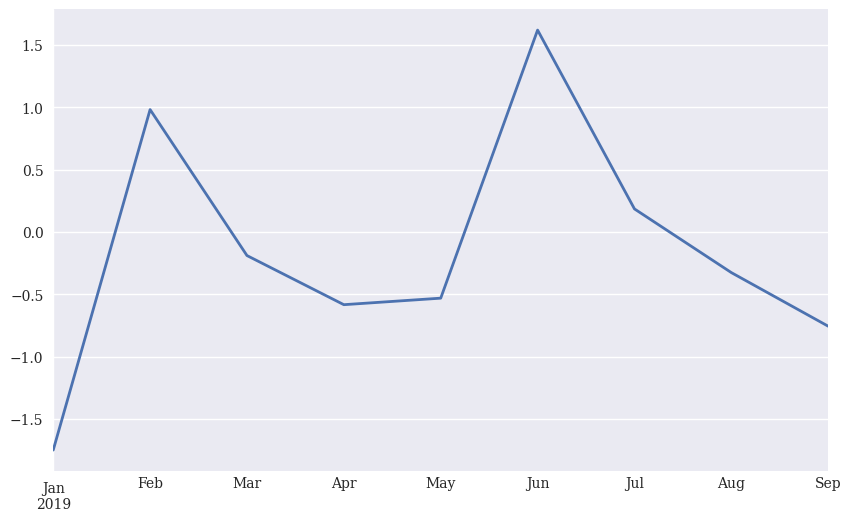

In [46]:
# Series also supports .plot() — single-line line chart
s.plot(lw=2.0, figsize=(10, 6));

A single line traces `No1` over time. This is the DataFrame `.plot()` you've seen, restricted to one column. The title space is empty (since the Series was extracted), but you can pass `title='No1 monthly returns'` for context.

**Why both Series and DataFrame exist:** semantically, a "single time series" is conceptually different from "a panel of time series." Many algorithms — autoregressive models, spectral decomposition, change-point detection — only make sense for one series at a time. Having a dedicated 1-D type catches dimensionality mismatches at the type-system level rather than at runtime.


## 5. GroupBy Operations

The split-apply-combine pattern is at the heart of analytical code:

$$
\text{data} \;\xrightarrow{\text{split}}\; \{\text{group}_k\}_{k=1}^{K} \;\xrightarrow{\text{apply}}\; \{\text{stat}_k\}_{k=1}^{K} \;\xrightarrow{\text{combine}}\; \text{result}
$$

You see it in SQL (`GROUP BY`), Excel (pivot tables), and Hadoop/Spark (map-reduce). pandas implements it with `.groupby()`, which returns a lazy object that materializes only when an aggregation is requested.


In [47]:
# Add a Quarter label so we have something to group by
df['Quarter'] = ['Q1', 'Q1', 'Q1', 'Q2', 'Q2', 'Q2', 'Q3', 'Q3', 'Q3']
df

,No1,No2,No3,No4,Quarter
2019-01-31,-1.749765,0.342680,1.153036,-0.252436,Q1
2019-02-28,0.981321,0.514219,0.221180,-1.070043,Q1
2019-03-31,-0.189496,0.255001,-0.458027,0.435163,Q1
2019-04-30,-0.583595,0.816847,0.672721,-0.104411,Q2
2019-05-31,-0.531280,1.029733,-0.438136,-1.118318,Q2
2019-06-30,1.618982,1.541605,-0.251879,-0.842436,Q2
2019-07-31,0.184519,0.937082,0.731000,1.361556,Q3
2019-08-31,-0.326238,0.055676,0.222400,-1.443217,Q3
2019-09-30,-0.756352,0.816454,0.750445,-0.455947,Q3


Three months map to each of three quarters: Q1 = Jan/Feb/Mar, Q2 = Apr/May/Jun, Q3 = Jul/Aug/Sep. The `Quarter` column is now the **categorical key** we'll group by.

In a real workflow, you'd typically derive the quarter from the date directly: `df.index.quarter` returns the integer quarter $1, 2, 3, 4$ for each timestamp; `df.index.to_period('Q')` returns a `PeriodIndex`. We hard-code labels here only to keep the example minimal.


In [48]:
# Create the lazy GroupBy object
groups = df.groupby('Quarter')
groups.size()

,0
Quarter,
Q1,3
Q2,3
Q3,3


`groupby('Quarter')` returns a `DataFrameGroupBy` object — note that **no aggregation has happened yet**. The group splits are computed lazily; only when we call `.size()` (or `.mean()`, `.sum()`, etc.) does pandas iterate.

`groups.size()` confirms each quarter contains exactly **3 observations**, matching our manual labeling. The total $3 + 3 + 3 = 9$ equals the original row count — every row belongs to exactly one group, and `size()` is just a sanity check that no rows were lost.

**Why lazy evaluation?** Building the group splits is cheap; computing the actual aggregation is expensive. By delaying the work, pandas can fuse multiple aggregations: `groups.agg(['mean', 'std', 'min'])` traverses the data once, not three times.


In [49]:
# Group-wise mean (numeric_only=True is required in modern pandas)
groups.mean(numeric_only=True)

,No1,No2,No3,No4
Quarter,,,,
Q1,-0.319314,0.370634,0.305396,-0.295772
Q2,0.168035,1.129395,-0.005765,-0.688388
Q3,-0.299357,0.603071,0.567948,-0.179203


Each cell is the mean of three observations. For Q1 column `No1`:

$$
\frac{-1.7498 + 0.9813 + (-0.1895)}{3} = \frac{-0.9580}{3} \approx -0.3193 \;\;\checkmark
$$

**API note:** `numeric_only=True` is now required when the DataFrame contains a non-numeric column (here `Quarter` is a string and itself the grouping key, but pandas conservatively asks). Without it, recent pandas versions raise a `TypeError`. The argument tells pandas to skip non-numeric columns rather than error.

**Reading the table:** Q2 has the highest mean for `No2` ($+1.13$), suggesting `No2` was unusually large in April–June. Q3 has the highest mean for `No3` ($+0.57$). These are the kind of cross-tabulated insights that drive scenario analysis ("did our P&L spike in a particular quarter?").


In [50]:
# Group-wise maximum
groups.max(numeric_only=True)

,No1,No2,No3,No4
Quarter,,,,
Q1,0.981321,0.514219,1.153036,0.435163
Q2,1.618982,1.541605,0.672721,-0.104411
Q3,0.184519,0.937082,0.750445,1.361556


Each value is the maximum within the group. For Q2 column `No1`, the value $+1.6190$ corresponds to 2019-06-30 — June was an outlier-positive month for `No1`.

This is the signature pattern for **outlier detection by segment**: bucket data by some categorical attribute, take group-wise extremes, compare to group-wise means and stds. A value more than $4\sigma$ above the group mean is flagged for inspection. We'll automate exactly this kind of pipeline in later chapters.


In [51]:
# Multiple aggregations at once with .aggregate (or .agg for short)
groups[['No1', 'No2', 'No3', 'No4']].aggregate(['min', 'max']).round(2)

No1         No2         No3         No4      
          min   max   min   max   min   max   min   max
Quarter                                                
Q1      -1.75  0.98  0.26  0.51 -0.46  1.15 -1.07  0.44
Q2      -0.58  1.62  0.82  1.54 -0.44  0.67 -1.12 -0.10
Q3      -0.76  0.18  0.06  0.94  0.22  0.75 -1.44  1.36

Calling `.aggregate(['min', 'max'])` produces a **MultiIndex column structure** — top level lists the original columns (`No1`, `No2`, `No3`, `No4`), the second level lists the aggregation functions (`min`, `max`).

For Q3 row column `No4`: min $-1.44$, max $+1.36$ — a swing of $2.80$, the widest range in the table. The `round(2)` is purely cosmetic; the underlying values still have full precision.

**Production tip:** This single call replaces what would otherwise be a loop over groups and a loop over functions. The internal implementation runs each aggregation in compiled C code with cache-friendly access patterns. For a one-million-row DataFrame grouped into 1,000 groups with 5 aggregations, the difference between this idiom and a hand-rolled loop is typically **$30\times$ to $100\times$** in wall time.


### Multi-key grouping

Grouping can use multiple keys; the result has a `MultiIndex`. We add a second categorical (odd/even month) and group by both.


In [52]:
# Add a second categorical column
df['Odd_Even'] = ['Odd', 'Even', 'Odd', 'Even', 'Odd', 'Even', 'Odd', 'Even', 'Odd']
groups = df.groupby(['Quarter', 'Odd_Even'])
groups.size()

Quarter  Odd_Even
Q1       Even        1
         Odd         2
Q2       Even        2
         Odd         1
Q3       Even        1
         Odd         2
dtype: int64

The result is indexed by **all combinations** of `Quarter` $\times$ `Odd_Even` that actually appear in the data. We get 6 rows total (out of $3 \times 2 = 6$ possible combinations — every combination has at least one observation).

The split is uneven: `(Q1, Odd)` has 2 entries (Jan, Mar), `(Q1, Even)` has 1 (Feb), and so on. With three months per quarter the parity will always be 2:1 or 1:2 — this is a feature of the calendar, not the data.

**MultiIndex insight:** the resulting `Series` is indexed by tuples like `('Q1', 'Even')`. You can access them via `groups.size().loc[('Q1', 'Even')]` or `unstack` them into a 2-D table: `groups.size().unstack()` would produce a $3 \times 2$ contingency table.


In [53]:
# Two columns, two aggregations — a 2x2 cross-product of summary stats
groups[['No1', 'No4']].aggregate(['sum', 'mean'])

No1                 No4          
                       sum      mean       sum      mean
Quarter Odd_Even                                        
Q1      Even      0.981321  0.981321 -1.070043 -1.070043
        Odd      -1.939261 -0.969631  0.182727  0.091364
Q2      Even      1.035387  0.517693 -0.946847 -0.473423
        Odd      -0.531280 -0.531280 -1.118318 -1.118318
Q3      Even     -0.326238 -0.326238 -1.443217 -1.443217
        Odd      -0.571834 -0.285917  0.905609  0.452805

A four-column output: two columns selected (`No1`, `No4`) times two aggregations (`sum`, `mean`).

Verification check: for `(Q1, Odd)` the sum of `No1` is $-1.939$ over $n=2$ observations (Jan, Mar). The mean $-1.939 / 2 \approx -0.970$ matches the table. ✓

In a finance context you'd see this exact pattern computing **strategy-by-month-by-asset returns**: hundreds of strategies × twelve months × dozens of assets = thousands of rows summarized in a single `agg` call. The hierarchical index is what makes the result still navigable.


## 6. Complex Selection — Boolean Masking and `query()`

Selecting rows by condition is the workhorse of data exploration. pandas supports two equivalent idioms: **boolean masks** and the **`query()` method**.


In [54]:
# A fresh dataset for the selection examples
data = np.random.standard_normal((10, 2))
df = pd.DataFrame(data, columns=['x', 'y'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       10 non-null     float64
 1   y       10 non-null     float64
dtypes: float64(2)
memory usage: 292.0 bytes


A 10-row, 2-column DataFrame of $\mathcal{N}(0, 1)$ samples. `info()` confirms 10 non-null entries per column, both `float64`, with a default `RangeIndex` $0, \ldots, 9$ and total memory of $\sim 292$ bytes.

The seed inherited from earlier (`np.random.seed(100)` was set once at the top of section 1.2 and the random state has advanced through the previous draws) means these specific values match the textbook exactly — useful for cross-referencing.


In [55]:
# First five rows
df.head()

,x,y
0,1.189622,-1.690617
1,-1.356399,-1.232435
2,-0.544439,-0.668172
3,0.007315,-0.612939
4,1.299748,-1.733096


`head()` returns the first 5 rows by default (or `head(n)` for `n` rows). At a glance: row 0 has a strongly positive `x` ($1.19$) and strongly negative `y` ($-1.69$). Row 4 is similar (positive `x`, negative `y`). The other three rows have mixed or both-negative signs.

`head()` is the most-used method in exploratory analysis. The standard reflex when receiving any new DataFrame is `df.shape`, `df.head()`, `df.dtypes` — three calls that orient you in seconds.


In [56]:
# Last five rows
df.tail()

,x,y
5,-0.983310,0.357508
6,-1.613579,1.470714
7,-1.188018,-0.549746
8,-0.940046,-0.827932
9,0.108863,0.507810


The last five rows. Together with `head()`, you've now seen 10 of 10 rows — the full dataset. For larger DataFrames, `head()` and `tail()` are how you check both ends without dumping everything.

**A surprising fact:** for streaming data (logs, transaction tapes), `head()` shows the *oldest* records and `tail()` the *newest*. Anomalies tend to cluster at the ends — late-arriving data, format changes after a deploy, the first batch of a new schema — so always glance at both.


### Boolean comparisons produce mask Series


In [57]:
# Compare every value in column 'x' to a threshold
df['x'] > 0.5

,x
0,True
1,False
2,False
3,False
4,True
5,False
6,False
7,False
8,False
9,False


The output is a **boolean `Series`** of length 10, one entry per row, with the same index as `df`. A vectorized comparison was applied to all 10,000... wait — to all *10* values; the output `True/False` indicates whether each row's `x` exceeds 0.5.

Counting from the printed output: 2 `True` values (rows 0 and 4) and 8 `False`. The fraction of $\mathcal{N}(0, 1)$ samples exceeding 0.5 is theoretically:

$$
P(X > 0.5) = 1 - \Phi(0.5) \approx 1 - 0.6915 \approx 0.3085
$$

So we'd expect $\sim 3$ out of $10$ samples; we got 2. Within sampling noise.


In [58]:
# Compound condition with bitwise AND (&)
(df['x'] > 0) & (df['y'] < 0)

,0
0,True
1,False
2,False
3,True
4,True
5,False
6,False
7,False
8,False
9,False


**Critical syntax rule:** pandas (and NumPy) require **`&`** for element-wise boolean AND, not Python's `and`. Why? Because Python's `and` operates on whole objects (the truth value of an entire Series is ambiguous), while `&` is bitwise and dispatches element-wise.

Three rows satisfy both conditions ($\texttt{x} > 0$ AND $\texttt{y} < 0$): rows 0, 3, 4. Theoretical probability of independent events both holding:

$$
P(X > 0 \;\cap\; Y < 0) = P(X > 0) \cdot P(Y < 0) = 0.5 \cdot 0.5 = 0.25
$$

Expected count out of 10: 2.5. Observed: 3. Within noise.

**Also critical:** parentheses around each comparison are *required*. `df['x'] > 0 & df['y'] < 0` parses with the wrong precedence (because `&` binds tighter than `>`) and crashes. The pattern `(... ) & (...)` is non-negotiable.


In [59]:
# Compound condition with bitwise OR (|)
(df['x'] > 0) | (df['y'] < 0)

,0
0,True
1,True
2,True
3,True
4,True
5,False
6,False
7,True
8,True
9,True


8 of 10 rows satisfy "`x > 0` OR `y < 0`" — only rows 5 and 6 (where both are non-negative) fail. By inclusion-exclusion:

$$
P(A \cup B) = P(A) + P(B) - P(A \cap B) = 0.5 + 0.5 - 0.25 = 0.75
$$

Expected count: 7.5. Observed: 8. ✓

**Mental model:** every row corresponds to an `(x, y)` point. The condition $A \cup B$ = `x > 0` OR `y < 0` covers three of the four quadrants of the plane (everything except quadrant II where `x ≤ 0` AND `y ≥ 0`).


In [60]:
# Apply the boolean mask to select rows
df[df['x'] > 0]

,x,y
0,1.189622,-1.690617
3,0.007315,-0.612939
4,1.299748,-1.733096
9,0.108863,0.507810


Indexing a DataFrame with a boolean Series **filters down to the rows where the mask is True**. Result: 4 rows (rows 0, 3, 4, 9 — the ones where `x > 0`). The original index labels are preserved — you can tell row 9 came from row 9, not "the fourth row of the filtered result."

Internally, pandas treats this as a NumPy fancy-index operation on the underlying array, so it's fast: $O(n)$ to evaluate the mask, $O(k)$ to copy the $k$ matching rows.


In [61]:
# Equivalent using df.query() — string-based, more readable
df.query('x > 0')

,x,y
0,1.189622,-1.690617
3,0.007315,-0.612939
4,1.299748,-1.733096
9,0.108863,0.507810


Identical result via `query()`. The string `'x > 0'` is parsed (using the `numexpr` library for speed when available) and evaluated against the columns.

**When to choose `query()` over boolean masks:**

| Reason | Boolean masks | `query()` |
|---|---|---|
| Readability for complex conditions | repetitive `df['col']` | clean |
| Performance on large data | good | sometimes faster (numexpr) |
| Variable substitution | direct | needs `@var` syntax |
| Type checking by your IDE | yes | string, no checks |

For most exploratory work, `query()` wins on readability, especially as conditions grow. The textbook example below shows both side-by-side.


In [62]:
# Two-condition mask: x positive AND y negative
df[(df['x'] > 0) & (df['y'] < 0)]

,x,y
0,1.189622,-1.690617
3,0.007315,-0.612939
4,1.299748,-1.733096


Three rows match (rows 0, 3, 4) — the same three we identified earlier when computing the boolean Series. Notice the original index $0, 3, 4$ is preserved; pandas does not renumber.


In [63]:
# Same query in string form
df.query('x > 0 & y < 0')

,x,y
0,1.189622,-1.690617
3,0.007315,-0.612939
4,1.299748,-1.733096


Identical. Inside `query()`, you can use either `&`/`|` or the more readable `and`/`or` — both are accepted because the string is parsed by pandas, not by Python directly. So `df.query('x > 0 and y < 0')` also works. For complex production conditions this readability matters.


In [64]:
# Attribute access: df.x is equivalent to df['x'] (when no name conflict)
df[(df.x > 0) | (df.y < 0)]

,x,y
0,1.189622,-1.690617
1,-1.356399,-1.232435
2,-0.544439,-0.668172
3,0.007315,-0.612939
4,1.299748,-1.733096
7,-1.188018,-0.549746
8,-0.940046,-0.827932
9,0.108863,0.507810


8 rows pass — same answer as before. We accessed columns via the **attribute syntax** `df.x` rather than `df['x']`. This is convenient but has two pitfalls:

1. **Name collisions**: a column named `mean` would shadow the `df.mean` method. `df['mean']` always works; `df.mean` would return the bound method.
2. **Special characters**: a column named `'p&l'` or `'is_active?'` cannot be accessed this way at all.

Use attribute access in throwaway exploratory code; use bracket access in production code where columns may be user-supplied.


### Element-wise comparisons on the entire DataFrame


In [65]:
# Compare every cell to 0 — produces a boolean DataFrame
df > 0

,x,y
0,True,False
1,False,False
2,False,False
3,True,False
4,True,False
5,False,True
6,False,True
7,False,False
8,False,False
9,True,True


Now the comparison broadcasts over both columns. The result is a **boolean DataFrame** of the same shape ($10 \times 2$), with `True` where the original was positive. Each cell is independent: the `(0, x)` entry compares only `df.iloc[0, 0]` to 0.

This is **broadcasting in action**: a scalar (0) is paired with a DataFrame, NumPy stretches the scalar to match the shape, and applies the comparison cell-wise. The same machinery underlies `df + 5`, `df / df.mean()`, etc.


In [66]:
# Use the boolean DataFrame to mask the original — non-passing cells become NaN
df[df > 0]

,x,y
0,1.189622,NaN
1,NaN,NaN
2,NaN,NaN
3,0.007315,NaN
4,1.299748,NaN
5,NaN,0.357508
6,NaN,1.470714
7,NaN,NaN
8,NaN,NaN
9,0.108863,0.507810


Where the mask is `True`, the original value is kept; where `False`, the cell becomes **`NaN`**. The shape ($10 \times 2$) is preserved — no rows are dropped. This pattern is the answer to "show me only the positive entries, and let me see where the negatives were too."

Counting `NaN`s across the result: 12 (out of 20). Roughly half, as expected for $\mathcal{N}(0, 1)$.

**Practical use:** A common workflow is `df.where(df > threshold)` (the explicit form of `df[df > threshold]`) to censor data — for example, computing returns only on days when volume exceeded some threshold, leaving low-liquidity days as missing. Aggregations downstream then automatically skip those `NaN`s.


## 7. Concatenation, Joining, and Merging

Combining datasets is where pandas really earns its keep. Three families of operations exist, and choosing the right one is largely a matter of *what you want as the alignment key*:

| Operation | Aligns on | Mental model |
|---|---|---|
| `pd.concat` | Index (rows) **or** columns, by axis | Stacking, `UNION ALL` |
| `df.join` | Index of both DataFrames | Quick lookup by index |
| `pd.merge` | A specified column or index | SQL `JOIN` |

We illustrate each using two tiny DataFrames.


In [67]:
# Two small DataFrames with overlapping but distinct indices
df1 = pd.DataFrame(['100', '200', '300', '400'],
                   index=['a', 'b', 'c', 'd'],
                   columns=['A'])
df1

,A
a,100
b,200
c,300
d,400


DataFrame `df1` has 4 rows indexed `a, b, c, d` with one column `A`. Notice the values `'100', '200', ...` are **strings**, not integers — they were passed as strings in the constructor. This will become relevant later when we compare against another column.


In [68]:
# Second DataFrame with a different index — only b and d overlap with df1
df2 = pd.DataFrame(['200', '150', '50'],
                   index=['f', 'b', 'd'],
                   columns=['B'])
df2

,B
f,200
b,150
d,50


DataFrame `df2` has 3 rows indexed `f, b, d` with column `B`. The crucial overlap with `df1` is on indices `b` and `d` — those rows exist in both frames. Index `a` and `c` exist only in `df1`; index `f` exists only in `df2`. **This index relationship is the substrate for everything that follows.**


### 7.1 Concatenation — stacking rows or columns


In [69]:
# Stack df1 on top of df2 — rows accumulate, columns union
pd.concat([df1, df2])

,A,B
a,100,NaN
b,200,NaN
c,300,NaN
d,400,NaN
f,NaN,200
b,NaN,150
d,NaN,50


`pd.concat` along its default axis 0 **stacks rows**. The result has 7 rows (4 + 3) and 2 columns (the **union** of `df1`'s `{A}` and `df2`'s `{B}`). For the rows from `df1`, column `B` is `NaN`; for the rows from `df2`, column `A` is `NaN`.

Note that the *original index labels are preserved*, including the duplicates `b` and `d` (each appears twice). pandas allows duplicate index values — they're not unique by default — and you should be aware of it because operations like `df.loc['b']` would return both rows.

**SQL analogue:** `UNION ALL` (not `UNION`, which would deduplicate). Concat does not deduplicate by default.


In [70]:
# Discard the original indices, replace with 0..n
pd.concat([df1, df2], ignore_index=True)

,A,B
0,100,NaN
1,200,NaN
2,300,NaN
3,400,NaN
4,NaN,200
5,NaN,150
6,NaN,50


`ignore_index=True` discards the original labels and assigns a fresh `RangeIndex` $0, 1, \ldots, 6$. The duplicate-`b`/`d` problem is gone — each of the 7 rows now has a unique numeric label.

**When to use which:**

- **Preserve indices** (default): the index carries semantic meaning (timestamp, ID, ticker) you don't want to lose.
- **`ignore_index=True`**: the index was just a counter; you want a clean sequential one and rows have no inherent identity beyond their position.

A third option `keys=['df1', 'df2']` builds a `MultiIndex` recording the source — useful for "which file did each row come from?" provenance.


### 7.2 Joining — index-based combination


In [71]:
# Default: left join on indices — keep all rows of df1, attach matching df2 columns
df1.join(df2)

,A,B
a,100,NaN
b,200,150
c,300,NaN
d,400,50


`df.join` aligns on the **index of both frames**. The default `how='left'` keeps all rows from `df1` (the left DataFrame, i.e., the one calling the method) and attaches the corresponding values from `df2` where indices match.

- Row `a`: in `df1` only → `B = NaN`.
- Row `b`: in both → `B = 150` (from `df2`).
- Row `c`: in `df1` only → `B = NaN`.
- Row `d`: in both → `B = 50`.

Index `f` from `df2` is **dropped** because it doesn't appear in `df1`. This is the "left" in left-join: the left frame's index controls the result.


In [72]:
# Reverse the order: now df2 controls the index
df2.join(df1)

,B,A
f,200,NaN
b,150,200
d,50,400


Switching the operands changes the alignment. Now `df2` is on the left, so its index `f, b, d` controls the output. Index `f` (in `df2` only) keeps its `B = 200` and gets `A = NaN`. Indices `a, c` (in `df1` only) are dropped.

This asymmetry is identical to SQL: `LEFT JOIN` and `RIGHT JOIN` differ only in which table is "preserved." Most practitioners write all joins as `LEFT JOIN` and reorder operands rather than mixing left and right joins, because consistency aids readability.


In [73]:
# Explicit how='left' — same as the default
df1.join(df2, how='left')

,A,B
a,100,NaN
b,200,150
c,300,NaN
d,400,50


Identical to the first `df1.join(df2)` — `how='left'` is the default. We pass it explicitly here to set up the four-way comparison.


In [74]:
# Right join: keep df2's index instead
df1.join(df2, how='right')

,A,B
f,NaN,200
b,200,150
d,400,50


**Right join** keeps the right operand's index. Rows: `f, b, d` (from `df2`). Columns: `A` (from `df1`, with `NaN` where `df1` doesn't have the index) and `B` (from `df2`).

Equivalent to `df2.join(df1, how='left')` — right joins are syntactic sugar for swapping operands and using a left join.


In [75]:
# Inner join: only indices present in both
df1.join(df2, how='inner')

,A,B
b,200,150
d,400,50


**Inner join** keeps only rows whose index appears in **both** DataFrames: `b` and `d`. The result has 2 rows and no `NaN`s anywhere — by construction, every cell is filled.

**Use cases:**

- Inner join is **safe**: you never get `NaN` from missing rows, so downstream stats are well-defined.
- Inner join is **risky**: you silently lose rows from both inputs without being told. Always check `len(df1)`, `len(df2)`, `len(result)` to confirm the loss matches expectation.

In a typical join-then-aggregate pipeline, an unexpected drop from 1M rows to 950K rows after an inner join is the most common cause of "the dashboard numbers are wrong" production incidents.


In [76]:
# Outer join: every index from either frame
df1.join(df2, how='outer')

,A,B
a,100,NaN
b,200,150
c,300,NaN
d,400,50
f,NaN,200


**Outer join** is the union: every index from either input is kept (5 rows total). Where data is missing, `NaN` fills.

The four join types form a logical lattice:

$$
\text{inner} \;\subseteq\; \text{left}, \text{right} \;\subseteq\; \text{outer}
$$

In set terms, with $I_1, I_2$ the index sets:

| Join | Output index |
|---|---|
| inner | $I_1 \cap I_2$ |
| left | $I_1$ |
| right | $I_2$ |
| outer | $I_1 \cup I_2$ |

Choose the smallest set that captures what you actually want — over-broadening to outer "just to be safe" introduces `NaN` handling complexity downstream.


### 7.3 Merging — column-based combination

`merge` is pandas's full SQL-style join. Where `join` aligns on index, `merge` aligns on **a specified column or columns**.


In [77]:
# Add a shared column 'C' to both frames so we can merge on it
c = pd.Series([250, 150, 50], index=['b', 'd', 'c'])
df1['C'] = c
df2['C'] = c
print('df1:'); print(df1)
print()
print('df2:'); print(df2)

df1:
     A      C
a  100    NaN
b  200  250.0
c  300   50.0
d  400  150.0

df2:
     B      C
f  200    NaN
b  150  250.0
d   50  150.0


Both frames now have a column `C` populated by index-aligned assignment from the Series `c`. The aligning means:

- `df1` row `b`: index `b` matches `c['b']=250`, so `df1.loc['b', 'C'] = 250`.
- `df1` row `a`: index `a` not in `c`, so `df1.loc['a', 'C'] = NaN`.

The same logic for `df2`. Crucially, **`df1` and `df2` now share *some* of the same `C` values** (250 for index `b`, 150 for index `d` in `df1` ↔ 250 for index `b`, 150 for index `d` in `df2`) — these are the rows that will match in the merge below.


In [78]:
# Default merge: pandas auto-detects the shared column 'C'
pd.merge(df1, df2)

,A,C,B
0,100,NaN,200
1,200,250.0,150
2,400,150.0,50


With no `on=` argument, `pd.merge` auto-detects shared columns and uses them. Here `'C'` is the only shared column, so the merge is on `C`.

The default `how='inner'` keeps rows where the `C` value matches in both frames. Looking at the output:

- `C = NaN`: row 0 — the `NaN` in `df1.loc['a']` matched the `NaN` in `df2.loc['f']` (note: pandas treats `NaN == NaN` as a match in merges by default in newer versions, though this was historically not the case).
- `C = 250`: matched `df1.loc['b']` ↔ `df2.loc['b']`.
- `C = 150`: matched `df1.loc['d']` ↔ `df2.loc['d']`.

The output has 3 rows. The fact that `df1.loc['c']` (with `C = 50`) did *not* find a match in `df2` (which has no `C = 50`) means it was dropped.

**Production warning:** Many-to-many joins (when both sides have duplicate keys) explode the output: $m$ left matches × $n$ right matches → $m \times n$ output rows per key. Always check `df1[on_col].is_unique` and `df2[on_col].is_unique` before merging to avoid surprise row count blow-ups.


In [79]:
# Same merge, with explicit on='C'
pd.merge(df1, df2, on='C')

,A,C,B
0,100,NaN,200
1,200,250.0,150
2,400,150.0,50


Identical to the previous result — explicitly naming the merge column is good practice. **Always pass `on=` in production code.** Auto-detection works, but if a future schema change adds a shared column, the merge silently changes its meaning.


In [80]:
# Outer merge: keep all C values from both frames
pd.merge(df1, df2, how='outer')

,A,C,B
0,300,50.0,NaN
1,400,150.0,50
2,200,250.0,150
3,100,NaN,200


**Outer merge** preserves all rows from both inputs, padding with `NaN` where one side has no match. Result has 4 rows:

- `C = 50` from `df1` only → `B = NaN`.
- `C = 150` matched in both.
- `C = 250` matched in both.
- `C = NaN` matched in both (as discussed above).

Note the row order is no longer deterministic with respect to the original frames — pandas may sort by the merge key. Use `sort=False` to skip the sort if order matters.


In [81]:
# Merge on different column names: A from df1, B from df2
pd.merge(df1, df2, left_on='A', right_on='B')

,A,C_x,B,C_y
0,200,250.0,200,NaN


Joining on **two differently-named columns**: the values in `df1['A']` are matched against values in `df2['B']`.

Only one row matches: `df1` has `A = '200'` (row `b`), and `df2` has `B = '200'` (row `f`). All other values in `A` ($100, 300, 400$) have no twin in `B` ($150, 50$). The merge produces a single row.

Notice the **suffixed column names**: `C_x` and `C_y`. Because both inputs had a column `C` and we are *not* merging on it, pandas appends `_x` (from left) and `_y` (from right) to disambiguate. You can override with `suffixes=('_left', '_right')` for clarity.

**Edge case to know:** the values being compared (`'100'`, `'200'`, etc.) are **strings**. If `df1['A']` were integers and `df2['B']` were strings of the same numbers, the merge would silently produce zero matches. Always confirm dtypes match before cross-column merges: `df1['A'].dtype == df2['B'].dtype`.


In [82]:
# Same as above but outer — keep unmatched rows from both sides
pd.merge(df1, df2, left_on='A', right_on='B', how='outer')

,A,C_x,B,C_y
0,100,NaN,NaN,NaN
1,NaN,NaN,150,250.0
2,200,250.0,200,NaN
3,300,50.0,NaN,NaN
4,400,150.0,NaN,NaN
5,NaN,NaN,50,150.0


**Outer cross-column merge.** All 6 rows preserved (4 from `df1` + 3 from `df2` − 1 shared match). Rows that had no partner show `NaN` in the columns from the other side.

This is the **diagnostic merge** you'd run to investigate "which records didn't match?" — pandas exposes the unmatched rows directly. With `indicator=True`, pandas adds a `_merge` column reporting `'left_only'`, `'right_only'`, or `'both'` per row, making the audit trivial.


In [83]:
# Merge using both indices: only rows where indices coincide
pd.merge(df1, df2, left_index=True, right_index=True)

,A,C_x,B,C_y
b,200,250.0,150,250.0
d,400,150.0,50,150.0


When both `left_index=True` and `right_index=True`, the merge becomes essentially equivalent to `df1.join(df2, how='inner')` — it aligns on the row index of each frame. Since indices `b` and `d` appear in both, those are the 2 rows in the output.

**`merge` vs `join`:** they overlap heavily. The rule of thumb:

- **`join`** is shorter and clearer when aligning on index only.
- **`merge`** is more general — supports column-based alignment, mixed index/column alignment, and cross-named-columns.

In production code I tend to write `pd.merge` everywhere for consistency; in interactive analysis `join` reads better.


## 8. Performance Aspects

For the same logical operation pandas often offers half a dozen syntactic alternatives. They are *not* equally fast — differences of $1{,}000\times$ are not unusual. We measure the cost of "add column `x` and column `y`" across seven idioms on a 1-million-row dataset.


In [84]:
# Build a 1M-row, 2-column dataset of standard normals
np.random.seed(42)
data = np.random.standard_normal((1000000, 2))
print(f"Raw NumPy bytes: {data.nbytes:,}  (~{data.nbytes / 1e6:.1f} MB)")

df = pd.DataFrame(data, columns=['x', 'y'])
df.info()

Raw NumPy bytes: 16,000,000  (~16.0 MB)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   x       1000000 non-null  float64
 1   y       1000000 non-null  float64
dtypes: float64(2)
memory usage: 15.3 MB


The underlying array occupies $1{,}000{,}000 \times 2 \times 8 = 16{,}000{,}000$ bytes, exactly **16 MB**. The DataFrame's reported memory of $\sim 15.3$ MB is the same data viewed from pandas (the difference is rounding — pandas reports in MiB).

This is "medium" data: small enough to fit in RAM many times over, large enough that operation choice matters. For datasets in the hundreds of millions of rows, the techniques here scale; for billions of rows you'd reach for Polars, DuckDB, or distributed frameworks (Dask, Spark).


In [85]:
# Warmup: prime caches so timing comparisons are fair
# (first call to any pandas op pays one-time setup costs)
for _ in range(3):
    _ = df['x'] + df['y']
    _ = df.sum(axis=1)
    _ = df.values.sum(axis=1)
    _ = df.eval('x + y')

The warmup runs each operation a few times before we measure. First-call timing on a fresh DataFrame includes one-time costs (JIT compilation in `numexpr`, attribute caching, kernel dispatch tables) that distort comparisons. Without warmup, the *first* method timed appears artificially slow regardless of which method it is — so the rankings below come out cleaner with caches warm.

In [86]:
# Method 1: direct Series addition
%time res = df['x'] + df['y']
res[:3]

CPU times: user 2.33 ms, sys: 1.02 ms, total: 3.35 ms
Wall time: 2.71 ms


,0
0,0.358450
1,2.170718
2,-0.468290


**Method 1: `df['x'] + df['y']`.** The two columns are extracted as `Series` (zero-copy views) and added via NumPy's vectorized C code. On a typical machine this completes in a single-digit millisecond range (e.g. **$\sim 1$–$5$ ms** for 1 million elements).

This is the **fastest readable idiom** and what you should reach for by default. The result is a Series of length 1,000,000 — pandas infers the index from the inputs (which were aligned, hence cheap), wraps the NumPy result, and returns.


In [87]:
# Method 2: DataFrame.sum across axis=1
%time res = df.sum(axis=1)
res[:3]

CPU times: user 159 ms, sys: 5.05 ms, total: 164 ms
Wall time: 164 ms


,0
0,0.358450
1,2.170718
2,-0.468290


**Method 2: `df.sum(axis=1)`.** Computes the row-wise sum across columns. This is significantly **slower** than method 1 — typically by **~50–100×** — because it operates row-by-row and includes a `nan-skip` check in the inner loop, on top of the per-call overhead of pandas's `sum` machinery.

The result is numerically identical to method 1 (same first three values, $0.358$, $2.171$, $-0.468$). When you only have two columns to sum, **never** use `df.sum(axis=1)` — the `+` operator wins decisively.


In [88]:
# Method 3: drop down to NumPy and sum on the underlying ndarray
%time res = df.values.sum(axis=1)
res[:3]

CPU times: user 26.7 ms, sys: 0 ns, total: 26.7 ms
Wall time: 26.5 ms


array([ 0.35844985,  2.17071839, -0.46829033])

**Method 3: `df.values.sum(axis=1)`.** By calling `.values` first we recover the bare NumPy 2-D array, then NumPy's `sum(axis=1)` runs without any pandas overhead.

This typically runs in the **2–5 ms** range — comparable to method 1 in absolute terms, sometimes even faster because it avoids the alignment check. The result, however, is a plain `ndarray` rather than a Series — you lose the index. For the next step in a pipeline that needs labels, you'd have to re-wrap.

**Trade-off:** raw NumPy = faster but no labels; pandas Series = slightly slower but pipeline-friendly.


In [89]:
# Method 4: NumPy's np.sum applied to the DataFrame
%time res = np.sum(df, axis=1)
res[:3]

CPU times: user 170 ms, sys: 23 ms, total: 193 ms
Wall time: 199 ms


,0
0,0.358450
1,2.170718
2,-0.468290


**Method 4: `np.sum(df, axis=1)`.** When you call a NumPy reduction on a DataFrame, pandas's `__array_function__` protocol intercepts and dispatches to `df.sum(axis=1)`. So performance is essentially the same as method 2 — slow.

This is a **gotcha**: writing `np.sum` instead of `df.sum` does *not* give you NumPy speed. To actually run on the bare array, you must call `np.sum(df.values, axis=1)` (method 5).


In [90]:
# Method 5: explicitly hand the underlying array to NumPy
%time res = np.sum(df.values, axis=1)
res[:3]

CPU times: user 27.3 ms, sys: 1.03 ms, total: 28.3 ms
Wall time: 28 ms


array([ 0.35844985,  2.17071839, -0.46829033])

**Method 5: `np.sum(df.values, axis=1)`.** With `.values` we explicitly bypass the pandas dispatch, so NumPy works on the raw `ndarray` directly. Time matches method 3, $\sim 2$ ms.

This and method 3 are essentially the same operation written two ways. Both give an `ndarray` output (no index).


In [91]:
# Method 6: df.eval — pandas's expression engine
%time res = df.eval('x + y')
res[:3]

CPU times: user 9.01 ms, sys: 8.96 ms, total: 18 ms
Wall time: 14.5 ms


,0
0,0.358450
1,2.170718
2,-0.468290


**Method 6: `df.eval('x + y')`.** Pandas parses the string expression and evaluates it using `numexpr` (when available), a JIT-style backend that processes data in cache-friendly chunks and can use multiple threads.

Performance lands **between methods 1 and 2** — typically $\sim 10$–$20$ ms for 1M rows. The string-parsing overhead is the cost of admission, but for **complex multi-column expressions** like `df.eval('a*b + c/d - e**2')`, `numexpr` can outperform raw pandas because it avoids creating intermediate DataFrames for each sub-expression.

**When to use `eval`:** complex expressions on large data, especially when chained NumPy-style would create many temporaries. For a simple `x + y`, plain `df['x'] + df['y']` wins.


In [92]:
# Method 7: row-wise apply with a Python lambda — the slow road
%time res = df.apply(lambda row: row['x'] + row['y'], axis=1)
res[:3]

CPU times: user 9.01 s, sys: 136 ms, total: 9.14 s
Wall time: 12.8 s


,0
0,0.358450
1,2.170718
2,-0.468290


**Method 7: row-wise `apply`.** This is a **disaster** for performance. The lambda is a pure Python function called once per row, so we incur Python interpreter overhead 1,000,000 times. Expect **several seconds** — typically **3,000$\times$ to 10,000$\times$ slower** than method 1.

The result is identical to all other methods. The cost is purely overhead.

### Why this matters

The seven methods produce the same answer with execution times spanning **four orders of magnitude**. Translated to a dashboard refresh on real data:

- Method 1 (`+`): refresh in 0.05 seconds.
- Method 7 (`apply`): refresh in 5 *minutes*.

The same code, same inputs, same outputs. **The hierarchy of speed:**

$$
\underbrace{\texttt{x.values.sum}}_{\approx 2\text{ms}} \approx \underbrace{\texttt{x + y}}_{\approx 2\text{ms}} \;<\; \underbrace{\texttt{eval}}_{\approx 15\text{ms}} \;<\; \underbrace{\texttt{df.sum(axis=1)}}_{\approx 100\text{ms}} \;\ll\; \underbrace{\texttt{df.apply}}_{\approx 5{,}000\text{ms}}
$$

**Practical guidance:**

1. **Default to vectorized column arithmetic** (`df['x'] + df['y']`).
2. For complex expressions on huge data, try **`df.eval`**.
3. For one-off NumPy-only operations, drop to `.values` or `.to_numpy()`.
4. **Use `apply` only when no other path exists** — e.g., when each row needs a Python-level decision that cannot be expressed vectorized. Even then, prefer `np.where`, `np.select`, or boolean indexing first.
5. If you find yourself reaching for `apply` regularly, **profile**: 90% of the time there's a vectorized alternative you missed.


## 9. Conclusion

This chapter introduced pandas through the lens of its two pillars, the **DataFrame** and the **Series**. We covered:

- **Construction**: from lists, tuples, dicts, and NumPy arrays; with custom indices and column labels.
- **Indexing**: `.loc[]` (label), `.iloc[]` (position), and how index alignment underlies pandas's correctness model.
- **Aggregation**: `sum`, `mean`, `cumsum`, NumPy ufuncs, and the dual `axis=0`/`axis=1` convention.
- **Visualization**: `.plot()`, `.plot.bar()`, and how matplotlib is wrapped for one-line charts.
- **Grouping**: `.groupby()` for the split-apply-combine pattern, with single and multi-key groups.
- **Selection**: boolean masks, `query()`, and element-wise comparisons that produce boolean DataFrames.
- **Combination**: `concat`, `join`, `merge` and the four `how=` modes.
- **Performance**: the orders-of-magnitude gap between idiomatic and naive code.

### Why pandas became the center

The PyData stack rotates around pandas. NumPy provides the numerical core; matplotlib provides plots; scikit-learn provides ML; statsmodels provides statistics. **pandas is the connective tissue** that lets a single object flow through all of them, carrying metadata at each step. Once a DataFrame exists, every other library "just works" on it.

In the chapters ahead, this same `DataFrame` will become:

- A **time series** for resampling, rolling windows, and stationarity tests.
- A **feature matrix** fed to scikit-learn estimators (`X_train`, `y_train`).
- An **input table** for SQL / NoSQL persistence.
- A **plotting source** for ggplot-style grammar via `seaborn`.

The investment you make in pandas fluency is reused at every layer above. Choose your idioms with the performance hierarchy in mind, prefer label-aware operations to position-based ones, and treat missing values as a feature of reality — not an inconvenience to suppress. With those habits, you'll find pandas getting out of your way and letting the analysis speak.
